# Generating and Evaluating Counterfactual Retrofit Explanations for Irish Homes using the SEAI Building Energy Rating (BER) Dataset

**Author:** Derek Lawless (A00048970)  
**Module:** AI Technologies Project (TECHH1001)  
**Programme:** PGDip Human-Centred AI Technologies, TU Dublin

## Install dependencies

In [ ]:
!pip install dice_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.1 MB/s eta 0:00:00


In [ ]:
import os
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import dice_ml
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from IPython.display import display
from tqdm.auto import tqdm
from google.colab import drive

drive.mount('/content/drive') # The dataset and SHAP checkpoints live on Drive.

# Change to e.g. './' to save locally.
DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Research Project"

RESULTS_DIR = f"{DRIVE_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning) # Supress sklearn/xgboost deprecation notices.
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

print("All imports successful.")

Mounted at /content/drive
All imports successful.


## Helper functions

In [ ]:
# ============================================================
# Counterfactual analysis helpers
# ============================================================

def cf_feature_changes(query_row, cf_row, feature_names):
    """Return list of (feature, old_val, new_val) tuples for features that changed."""
    return [
        (feat, query_row[feat], cf_row[feat])
        for feat in feature_names
        if query_row[feat] != cf_row[feat]
    ]


def check_plausibility(changes, directional_constraints, cf_label):
    """Flag directional constraint violations in a single counterfactual.

    `directional_constraints` maps a feature name to "increasing" or
    "decreasing" - the only direction that change is allowed to move in
    (e.g. wall U-value should only decrease for a plausible retrofit).
    """
    issues = []
    for feat, old_val, new_val in changes:
        if feat not in directional_constraints:
            continue
        direction = directional_constraints[feat]
        if direction == "decreasing" and new_val > old_val:
            issues.append(f"{cf_label}: {feat} increased ({old_val:.2f}->{new_val:.2f})")
        elif direction == "increasing" and new_val < old_val:
            issues.append(f"{cf_label}: {feat} decreased ({old_val:.2f}->{new_val:.2f})")
    return issues


def decode_change(feat, old_val, new_val, cat_encoders):
    """Format a single feature change as a readable string.

    Categorical features are decoded back to their original labels via
    `cat_encoders`; if decoding fails (e.g. value out of range) or the
    feature isn't categorical, the raw numeric values are shown instead.
    """
    if feat in cat_encoders:
        try:
            old_label = cat_encoders[feat].inverse_transform([int(old_val)])[0]
            new_label = cat_encoders[feat].inverse_transform([int(new_val)])[0]
            return f"  {feat}: {old_label} -> {new_label}"
        except (ValueError, IndexError):
            pass
    return f"  {feat}: {old_val:.3f} -> {new_val:.3f}"


# ============================================================
# Model evaluation helpers
# ============================================================

def evaluate_model(y_true, y_pred, labels, scale_name):
    """Print accuracy, macro-F1, and classification report for one BER scale."""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\n{'=' * 60}")
    print(f"{scale_name} EVALUATION")
    print(f"{'=' * 60}")
    print(f"Accuracy: {acc:.4f}, F1 (macro): {f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    return acc, f1


def plot_confusion(y_true, y_pred, labels, title, cmap, ax):
    """Plot one confusion matrix heatmap on the given axes."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=labels, yticklabels=labels,
        ax=ax, cbar=False,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")


# ============================================================
# SHAP helpers
# ============================================================

def shap_global_importance(sv, feature_names):
    """Compute mean |SHAP| per feature, averaged across all classes. Returns a sorted DataFrame."""
    mean_abs = np.abs(sv).mean(axis=0).mean(axis=1)  # (features,)
    return (
        pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_abs})
        .sort_values("Mean |SHAP|", ascending=False)
        .reset_index(drop=True)
    )


def shap_to_array(shap_values):
    """Normalise SHAP output to (samples, features, classes) regardless of version.

    Different SHAP versions/explainers return different shapes for
    multi-class output (sometimes classes-first, sometimes samples-first,
    sometimes no class axis at all for binary problems); this collapses
    them all to one consistent (samples, features, classes) layout.
    """
    sv = np.array(shap_values)
    if sv.ndim == 3 and sv.shape[0] < sv.shape[1]: # (classes, samples, features).
        sv = sv.transpose(1, 2, 0)
    if sv.ndim == 2: # binary: add class axis.
        sv = sv[:, :, np.newaxis]
    return sv # always (samples, features, classes).

## 1. Data loading

**Note:** Using Raushan et al. (2025) cleaned dataset (see https://pmc.ncbi.nlm.nih.gov/articles/PMC11803240/).


### 1.1. Load dataset

Reads the SEAI CSV, reports shape, dtypes, and top missingness, to
sanity-check the source file before any transformation.

In [ ]:
DATA_FILE = f"{DRIVE_DIR}/cleaned_and_validated_epc_dataset_20230725.csv"
CHECKPOINT_DIR = f"{DRIVE_DIR}/shap_chunks"

# low_memory=False avoids dtype-guessing errors on large files which
# mix numeric and text values within several columns.
df_raw = pd.read_csv(DATA_FILE, low_memory=False)
print(f"Loaded {len(df_raw):,} records with {df_raw.shape[1]} columns.")
print("\nColumn names:")
print("\n".join(df_raw.columns))

display(df_raw.head())

print("\nData types:")
print(df_raw.dtypes.value_counts())

print(f"\nMissing values (top 20):")
print(df_raw.isnull().sum().sort_values(ascending=False).head(20))

Loaded 709,060 records with 215 columns.

Column names:
CountyName
DwellingTypeDescr
Year_of_Construction
TypeofRating
EnergyRating
BerRating
GroundFloorArea(sq m)
UValueWall
UValueRoof
UValueFloor
UValueWindow
UvalueDoor
WallArea
RoofArea
FloorArea
WindowArea
DoorArea
NoStoreys
CO2Rating
MainSpaceHeatingFuel
MainWaterHeatingFuel
HSMainSystemEfficiency
MultiDwellingMPRN
TGDLEdition
MPCDERValue
HSEffAdjFactor
HSSupplHeatFraction
HSSupplSystemEff
WHMainSystemEff
WHEffAdjFactor
SupplSHFuel
SupplWHFuel
SHRenewableResources
WHRenewableResources
NoOfChimneys
NoOfOpenFlues
NoOfFansAndVents
NoOfFluelessGasFires
DraftLobby
VentilationMethod
FanPowerManuDeclaredValue
HeatExchangerEff
StructureType
SuspendedWoodenFloor
PercentageDraughtStripped
NoOfSidesSheltered
PermeabilityTest
PermeabilityTestResult
TempAdjustment
HeatSystemControlCat
HeatSystemResponseCat
NoCentralHeatingPumps
CHBoilerThermostatControlled
NoOilBoilerHeatingPumps
OBBoilerThermostatControlled
OBPumpInsideDwelling
NoGasBoilerHea

,CountyName,DwellingTypeDescr,Year_of_Construction,TypeofRating,EnergyRating,BerRating,GroundFloorArea(sq m),UValueWall,UValueRoof,UValueFloor,UValueWindow,UvalueDoor,WallArea,RoofArea,FloorArea,WindowArea,DoorArea,NoStoreys,CO2Rating,MainSpaceHeatingFuel,MainWaterHeatingFuel,HSMainSystemEfficiency,MultiDwellingMPRN,TGDLEdition,MPCDERValue,...,SecondWallUValue,SecondWallIsSemiExposed,SecondWallAgeBandId,SecondWallTypeId,ThirdWallType_Description,ThirdWallArea,ThirdWallUValue,ThirdWallIsSemiExposed,ThirdWallAgeBandId,ThirdWallTypeId,SA_Code,prob_smarea_error_0corr,prob_smarea_error_100corr,RER,RenewEPnren,RenewEPren,CPC,EPC,age_band_bin,AgeBand,PUValueWall,PUValueRoof,UIDHex,County,ThermalEra
0,Co. Mayo,End of terrace house,1950,Final,B2,122.68,74.25,0.23,0.16,0.17,2.59,1.40,78.99,45.45,45.45,8.05,4.29,2,29.71,Heating Oil,Heating Oil,95.0,NO,0,38.16,...,0.17,No,11.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9108.7,0.0,0.780,0.654,"(1949.0, 1966.0]",D,0.23,0.16,0x7fa02,Mayo,Pre
1,Dublin 18,Detached house,1960,Final,C1,154.93,158.67,0.26,0.17,0.31,2.52,3.67,150.45,93.61,92.07,32.24,4.14,2,33.78,Mains Gas,Mains Gas,90.5,NO,2,31.04,...,0.27,No,NaN,7.0,Timber Frame,11.76,0.25,No,NaN,8.0,267089008,5.562300e-07,0.002500,NaN,NaN,NaN,1.029,1.009,"(1949.0, 1966.0]",D,0.26,0.17,0x13005,Dublin,Pre
2,Co. Clare,Detached house,1970,Final,B1,87.17,287.20,0.21,0.16,0.19,1.25,3.00,161.29,234.92,167.10,70.43,5.55,2,19.63,Heating Oil,Heating Oil,94.8,NO,3,27.51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37111001,1.255784e-02,0.012558,NaN,NaN,NaN,0.681,0.639,"(1966.0, 1977.0]",E,0.21,0.16,0x21a74,Clare,Pre
3,Cork City,Mid-terrace house,1917,Final,B3,133.25,88.29,0.24,0.19,0.18,1.40,3.00,92.36,46.69,46.90,19.29,2.10,2,23.85,Mains Gas,Mains Gas,90.2,NO,1,29.33,...,0.27,No,NaN,9.0,Other,29.88,0.19,No,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1900.0, 1929.0]",B,0.24,0.19,0xa1d24,Cork,Pre
4,Co. Donegal,House,1900,Final,C1,155.60,204.80,0.27,0.24,0.28,2.80,3.00,201.80,107.40,107.40,30.02,5.76,2,39.96,Heating Oil,Heating Oil,85.0,NO,1,36.72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(-inf, 1900.0]",A,0.27,0.24,0x6913,Donegal,Pre



Data types:
float64    150
object      56
int64        9
Name: count, dtype: int64

Missing values (top 20):
ThirdEnerConsumedComment     709029
SecondEnerConsumedComment    708996
ThirdEnerProdComment         708951
SecondEnerProdComment        708282
FirstEnerConsumedComment     708022
VolumeOfPreHeatStore         705815
gsdSHRenewableResources      701604
gsdWHRenewableResources      701604
ThirdHeatGenPlantEff         699201
ThirdPercentageHeat          699201
ThirdBoilerFuelType          699201
SecondBoilerFuelType         699200
SecondPercentageHeat         699200
SecondHeatGenPlantEff        699200
SolarHeatFraction            699200
SolarSpaceHeatingSystem      699200
gsdHSSupplSystemEff          699179
FirstBoilerFuelType          699179
FirstPercentageHeat          699179
FirstHeatGenPlantEff         699179
dtype: int64


## 2. Data cleaning and feature selection


### 2.1. Feature selection

Defines the candidate list of manually inputted building characteristics (the fields a retrofit can actually change) and filters it against the columns available in this dataset version, since five planned fields were dropped upstream by the data provider.

In [ ]:
COL_BER_LABEL = "EnergyRating" # Categorical: A1, A2, ..., G
COL_BER_NUMERIC = "BerRating"  # Numeric: kWh/m²/yr

# Manually inputted building characteristics (BER assessor fields).
FEATURE_COLS = [
    "DwellingTypeDescr", "Year_of_Construction", "GroundFloorArea", "NoStoreys",
    "UValueWall", "WallArea", "UValueRoof", "RoofArea", "InsulationThicknessRoof",
    "UValueFloor", "FloorArea", "UValueWindow", "WindowArea", "GlazingType",
    "MainSpaceHeatingFuel", "HSMainSystemEfficiency",
    "MainWaterHeatingFuel", "WHMainSystemEfficiency",
    "VentilationType", "HSSupplSystemEfficiency",
]

# Five planned fields aren't present in the dataset,
# so the candidate list is filtered down to what's present.
available = [c for c in FEATURE_COLS if c in df_raw.columns]
missing = [c for c in FEATURE_COLS if c not in df_raw.columns]
if missing:
    print(f"Columns not found (skipped): {missing}")
FEATURE_COLS = available

print(f"Using {len(FEATURE_COLS)} features.")

Columns not found (skipped): ['InsulationThicknessRoof', 'GlazingType', 'WHMainSystemEfficiency', 'VentilationType', 'HSSupplSystemEfficiency']
Using 15 features.


### 2.2. Missing data handling

Builds the working dataframe from the selected features, drops rows
missing a target label, and imputes remaining gaps (median for numeric,
mode for categorical). No rows are expected to be dropped here since the
source file was pre-filtered.

In [ ]:
# Build working dataframe, drop missing targets, impute remaining gaps.
df = df_raw[FEATURE_COLS + [COL_BER_LABEL, COL_BER_NUMERIC]].copy()
df = df.dropna(subset=[COL_BER_LABEL, COL_BER_NUMERIC])

# Require at least half the feature columns to be populated; a row failing
# this is treated as too sparse to impute reliably.
df = df.dropna(thresh=len(FEATURE_COLS) // 2 + 1, subset=FEATURE_COLS)

for col in FEATURE_COLS:
    if df[col].dtype in ["float64", "int64"]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Working dataset: {len(df):,} records, {len(FEATURE_COLS)} features.")

Working dataset: 709,060 records, 15 features.


---
## 3. BER scale mapping

### 3.1. Define 15→8 point mapping
Encodes the May 2026 scale-simplification rule as a lookup table and validates that all labels in the raw data are recognised sub-bands.

- The BER scale changed on 24 May 2026 from 15 categories to 8 (https://www.seai.ie/ber/new-simplified-scale)
- The model is trained on the original 15-point scale, with results also reported on the new 8-point scale for comparison

| New Scale | Old Scale Equivalent |
|-----------|---------------------|
| A0        | New (zero emission) |
| A         | A1, A2, A3          |
| B         | B1, B2, B3          |
| C         | C1, C2, C3          |
| D         | D1, D2              |
| E         | E1, E2              |
| F         | F                   |
| G         | G                   |

In [ ]:
BER_15_ORDER = ["A1", "A2", "A3", "B1", "B2", "B3",
                "C1", "C2", "C3", "D1", "D2", "E1", "E2", "F", "G"]

MAP_15_TO_8 = {
    "A1": "A", "A2": "A", "A3": "A", "B1": "B", "B2": "B", "B3": "B",
    "C1": "C", "C2": "C", "C3": "C", "D1": "D", "D2": "D",
    "E1": "E", "E2": "E", "F": "F", "G": "G",
}
BER_8_ORDER = ["A0", "A", "B", "C", "D", "E", "F", "G"]

# Some assessors recorded labels with trailing whitespace (e.g. "C1 ").
df[COL_BER_LABEL] = df[COL_BER_LABEL].str.strip()
valid = df[COL_BER_LABEL].isin(BER_15_ORDER)
print(f"Valid BER labels: {valid.sum():,} / {len(df):,}")
df = df[valid].copy() # Drop any label outside the 15 recognised sub-bands.

df["BER_8"] = df[COL_BER_LABEL].map(MAP_15_TO_8)

print("\n8-point distribution:")
print(df["BER_8"].value_counts().reindex(BER_8_ORDER))

Valid BER labels: 709,060 / 709,060

8-point distribution:
BER_8
A0         NaN
A      31306.0
B      89077.0
C     288967.0
D     162999.0
E      71588.0
F      30370.0
G      34753.0
Name: count, dtype: float64


## 4. Exploratory data analysis

### 4.1. BER label distributions
Bar charts of dwelling counts on both scales, to show the class imbalance the model must contend with.

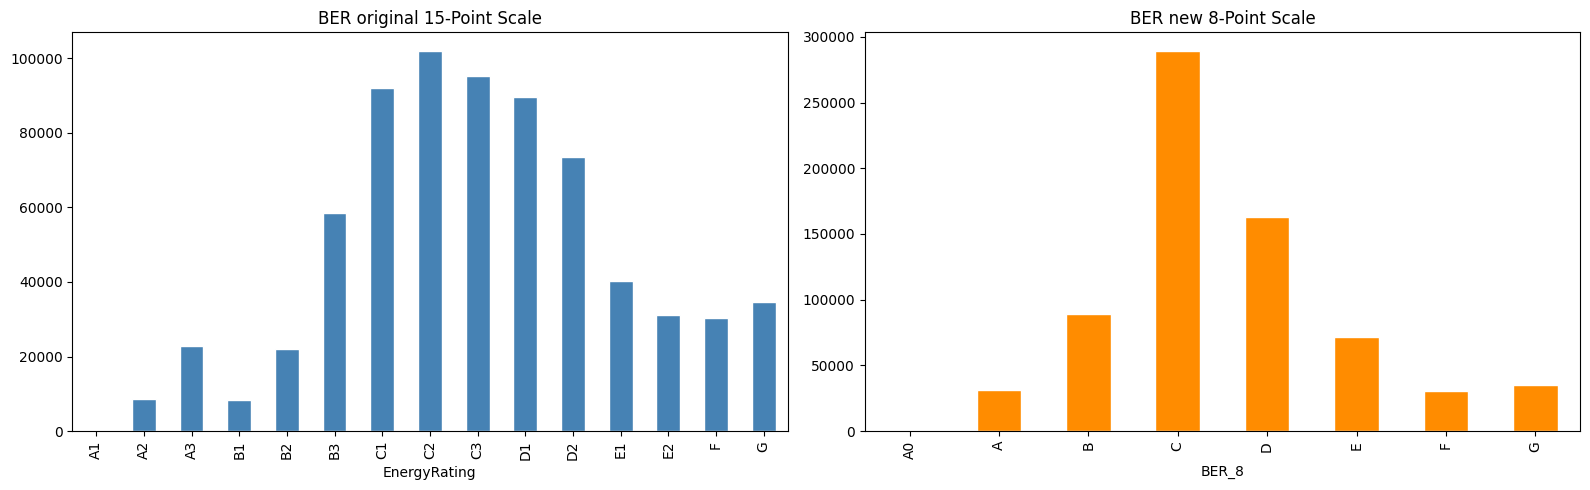

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# reindex() enforces BER ordering, since value_counts() alone would sort
# bars by frequency rather than by band.
df[COL_BER_LABEL].value_counts().reindex(BER_15_ORDER).plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("BER original 15-Point Scale")

df["BER_8"].value_counts().reindex(BER_8_ORDER).plot(
    kind="bar", ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("BER new 8-Point Scale")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig_ber_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.1. Numeric feature distributions
Histograms and summary statistics for the 11 continuous features, surfacing the `Year_of_Construction` anomaly.

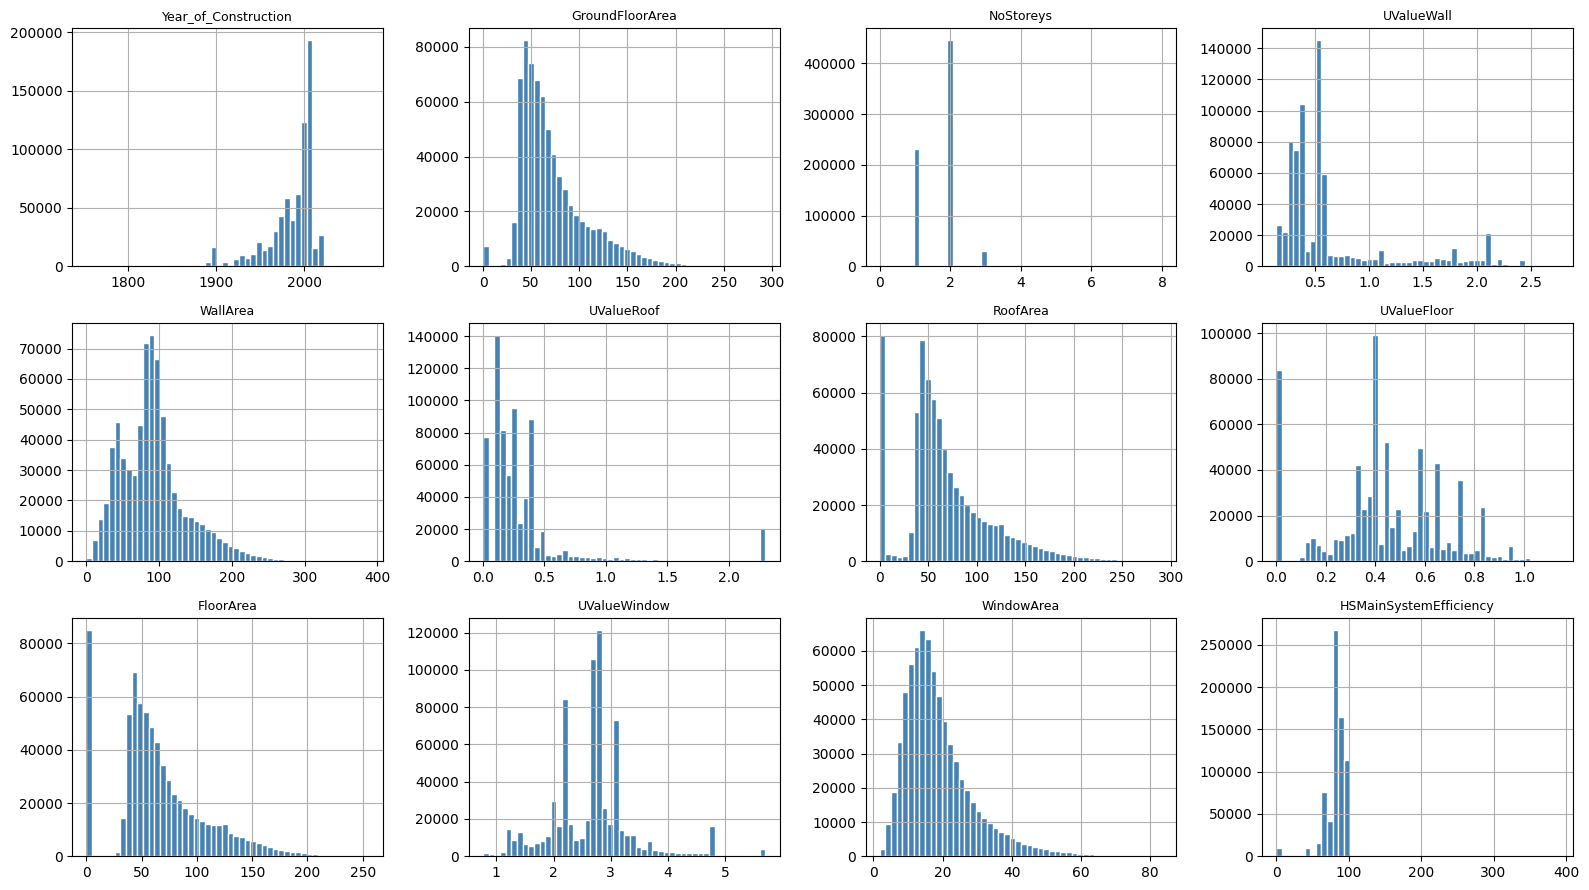

,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,HSMainSystemEfficiency
count,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00,709060.00
mean,1985.07,72.11,1.72,0.66,92.04,0.34,68.19,0.44,65.77,2.69,18.86,85.44
std,29.15,35.85,0.54,0.54,46.41,0.44,46.14,0.23,42.23,0.74,10.44,31.84
min,1753.00,0.00,0.00,0.14,0.17,0.00,0.00,0.00,0.00,0.77,1.80,0.00
25%,1975.00,46.77,1.00,0.32,59.26,0.13,42.34,0.34,42.39,2.20,11.86,78.10
50%,1997.00,61.72,2.00,0.54,87.71,0.23,58.25,0.41,58.00,2.71,16.40,85.30
75%,2004.00,87.06,2.00,0.60,110.77,0.40,88.82,0.60,85.86,3.00,23.02,91.10
max,2073.00,293.46,8.00,2.76,388.18,2.30,290.78,1.14,255.60,5.70,83.48,389.90


In [ ]:
numeric_features = df[FEATURE_COLS].select_dtypes(include=["float64","int64"]).columns.tolist()

if numeric_features:
    n_cols = 4
    n_rows = (len(numeric_features) + n_cols - 1) // n_cols # Ceiling division to fit all features.
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_features):
        df[col].hist(bins=50, ax=axes[i], color="steelblue", edgecolor="white")
        axes[i].set_title(col, fontsize=9)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False) # Hide leftover empty subplots in the grid.
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/fig_feature_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

display(df[numeric_features].describe().round(2))

## 5. Feature encoding and train/test split

### 5.1. Encode features and split data
Label-encodes categorical features and the BER target, then performs an 80/20 stratified split so rare sub-bands are proportionally represented in both sets.

In [ ]:
cat_features = df[FEATURE_COLS].select_dtypes(include="object").columns.tolist()
num_features = df[FEATURE_COLS].select_dtypes(include=["float64","int64"]).columns.tolist()

cat_encoders = {}
df_encoded = df.copy()
for col in cat_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    # Retained so DiCE counterfactual values can be decoded back to
    # their original labels later.
    cat_encoders[col] = le

# Target: fit only on labels present (contiguous 0..N-1 for XGBoost).
labels_present = [l for l in BER_15_ORDER if l in df_encoded[COL_BER_LABEL].values]
print(f"Labels present ({len(labels_present)}): {labels_present}")

target_encoder = LabelEncoder()
target_encoder.fit(labels_present)
y = target_encoder.transform(df_encoded[COL_BER_LABEL])
X = df_encoded[FEATURE_COLS].values
feature_names = FEATURE_COLS

# stratify=y preserves each sub-band's proportion in both splits, which
# matters given how rare some bands are (e.g. A1 has only 15 test rows
# once split).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

Labels present (15): ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'D1', 'D2', 'E1', 'E2', 'F', 'G']
Train: 567,248, Test: 141,812


## 6. Gradient-boosted model training (XGBoost)

Gradient-boosted model chosen because:
- Strong performance on tabular data with mixed feature types
- Native support for SHAP TreeExplainer (exact, not approximate)
- Handles missing values and class imbalance

### 6.1. Fit model
Trains the classifier with fixed default hyperparameters (no tuning performed) on the 15-point target.

In [ ]:
# Fixed hyperparameters using ommon defaults, not the output of a tuning
# search (see Section 8 of the report for planned future work).
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(labels_present), # Only sub-bands actually present in training data.
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss",
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50, # Log every 50th boosting round.
)

print("\nTraining complete.")

[0]	validation_0-mlogloss:2.26323
[50]	validation_0-mlogloss:1.42274
[100]	validation_0-mlogloss:1.32534
[150]	validation_0-mlogloss:1.28424
[200]	validation_0-mlogloss:1.26041
[250]	validation_0-mlogloss:1.24458
[299]	validation_0-mlogloss:1.23378

Training complete.


## 7. Dual BER scale evaluation (15-point and 8-point)

### 7.1. Accuracy and F1 by scale
Computes accuracy/macro-F1 on both the native 15-point scale and the collapsed 8-point scale, since most reported error is expected to be sub-band confusion.

In [ ]:
y_pred = model.predict(X_test)
y_test_labels = target_encoder.inverse_transform(y_test)
y_pred_labels = target_encoder.inverse_transform(y_pred)

# 15-point.
acc_15, f1_15 = evaluate_model(y_test_labels, y_pred_labels, labels_present, "15-POINT SCALE")

# Map true and predicted labels to the 8-point scale independently, since
# a misclassification can still land in the correct 8-point band.
y_test_8 = pd.Series(y_test_labels).map(MAP_15_TO_8).values
y_pred_8 = pd.Series(y_pred_labels).map(MAP_15_TO_8).values
labels_8_present = [l for l in BER_8_ORDER if l in set(y_test_8) | set(y_pred_8)]
acc_8, f1_8 = evaluate_model(y_test_8, y_pred_8, labels_8_present, "8-POINT SCALE")


15-POINT SCALE EVALUATION
Accuracy: 0.4774, F1 (macro): 0.5423

              precision    recall  f1-score   support

          A1       1.00      0.40      0.57        15
          A2       0.89      0.78      0.83      1705
          A3       0.88      0.92      0.90      4542
          B1       0.70      0.56      0.62      1680
          B2       0.63      0.47      0.54      4413
          B3       0.51      0.51      0.51     11722
          C1       0.45      0.51      0.47     18390
          C2       0.40      0.41      0.41     20370
          C3       0.40      0.34      0.37     19032
          D1       0.42      0.44      0.43     17919
          D2       0.44      0.55      0.49     14681
          E1       0.39      0.25      0.30      8075
          E2       0.39      0.32      0.35      6243
           F       0.50      0.55      0.52      6074
           G       0.83      0.82      0.82      6951

    accuracy                           0.48    141812
   macro avg   

### 7.2. Confusion matrices
Visualises where the model's errors land, to check whether they're adjacent-band slips or genuine misclassifications.

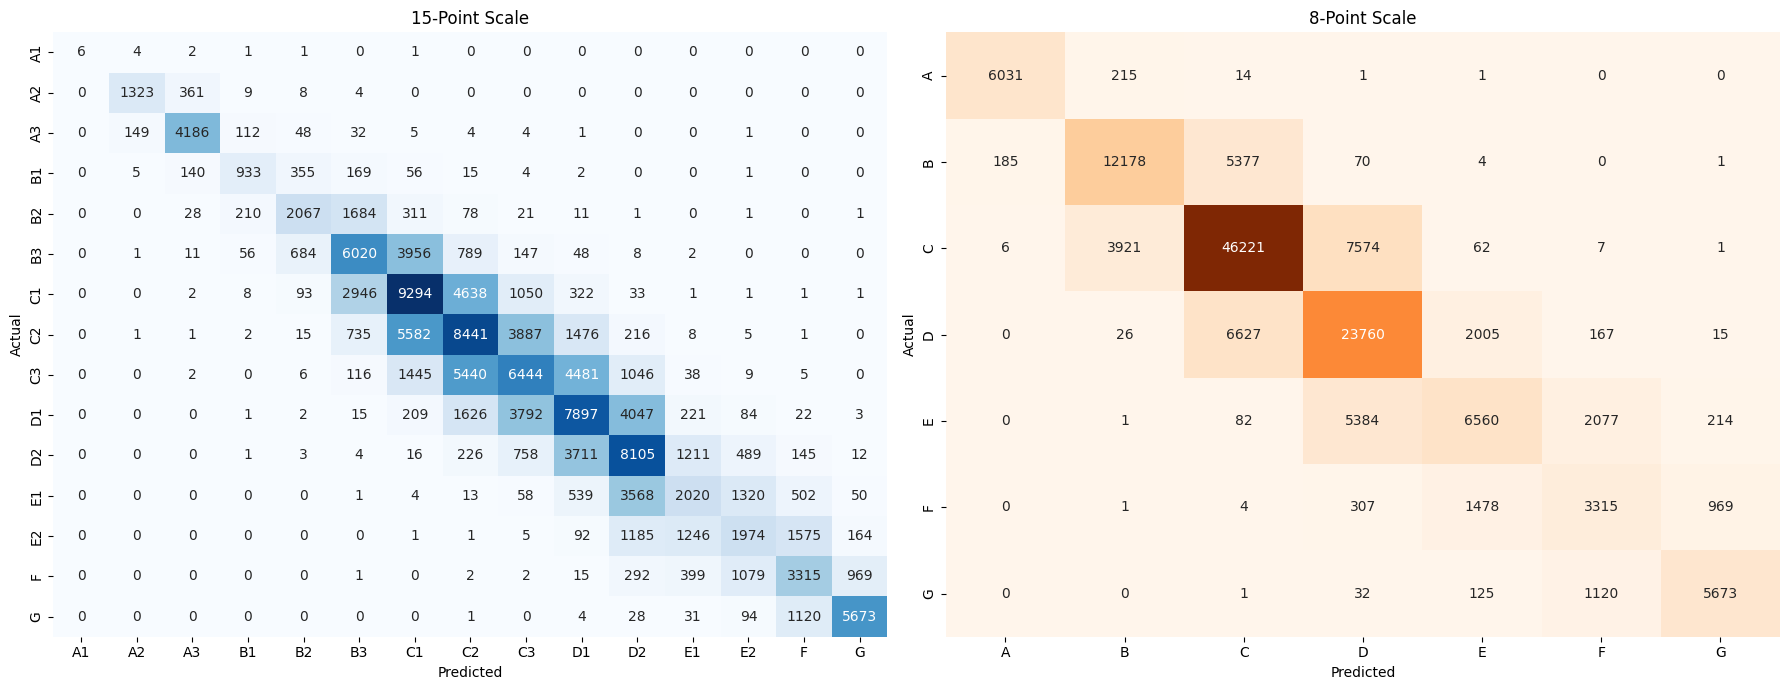

15-point 47.7% -> 8-point 73.2%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_confusion(y_test_labels, y_pred_labels, labels_present,
               "15-Point Scale", "Blues", axes[0])
plot_confusion(y_test_8, y_pred_8, labels_8_present,
               "8-Point Scale", "Oranges", axes[1])
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"15-point {acc_15:.1%} -> 8-point {acc_8:.1%}")

### 7.3. Per-class F1 comparison
Per-class F1 comparison, distinguishing genuinely reliable classes from those whose accuracy is undermined by low test-set support.

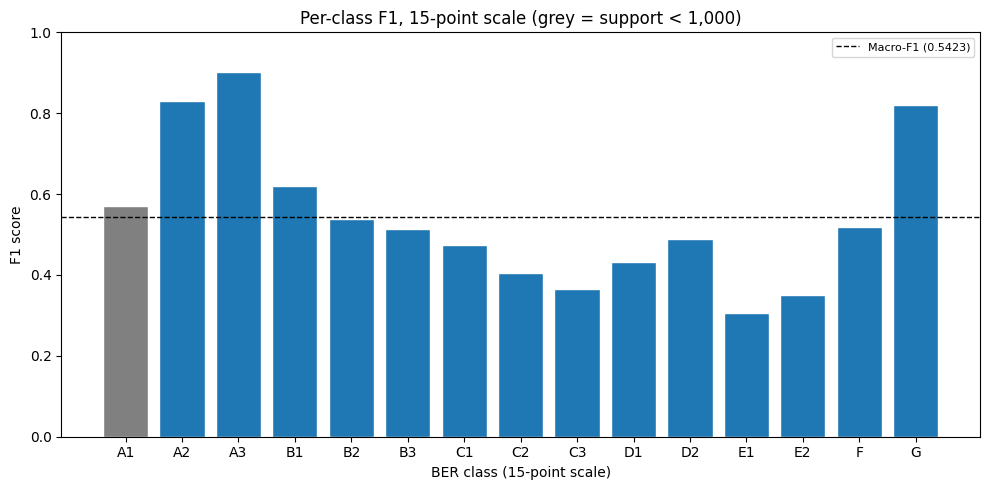

 A1: F1=0.571  support=15.0
 A2: F1=0.830  support=1705.0
 A3: F1=0.903  support=4542.0
 B1: F1=0.619  support=1680.0
 B2: F1=0.537  support=4413.0
 B3: F1=0.513  support=11722.0
 C1: F1=0.473  support=18390.0
 C2: F1=0.405  support=20370.0
 C3: F1=0.366  support=19032.0
 D1: F1=0.432  support=17919.0
 D2: F1=0.488  support=14681.0
 E1: F1=0.305  support=8075.0
 E2: F1=0.349  support=6243.0
  F: F1=0.520  support=6074.0
  G: F1=0.821  support=6951.0


In [ ]:
# Per-class F1 and support on the 15-point scale, alongside the confusion
# matrices above: a confusion matrix shows where errors land between
# classes, this shows how reliable each class's estimate is on its own.
report_dict = classification_report(
    y_test_labels, y_pred_labels, labels=labels_present,
    output_dict=True, zero_division=0,
)
f1_by_class = [report_dict[label]["f1-score"] for label in labels_present]
support_by_class = [report_dict[label]["support"] for label in labels_present]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["tab:blue" if s >= 1000 else "gray" for s in support_by_class]
ax.bar(labels_present, f1_by_class, color=bar_colors, edgecolor="white")
ax.axhline(f1_15, color="black", linestyle="--", linewidth=1,
           label=f"Macro-F1 ({f1_15:.4f})")
ax.set_ylim(0, 1.0)
ax.set_xlabel("BER class (15-point scale)")
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1, 15-point scale (grey = support < 1,000)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig_f1_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

for label, f1, support in zip(labels_present, f1_by_class, support_by_class):
    print(f"{label:>3}: F1={f1:.3f}  support={support}")

## 8. SHAP analysis

SHAP produces global feature importance and local explanations for selected dwellings.

### 8.1. Compute full-test-set SHAP values

Runs XGBoost's native `pred_contribs` in checkpointed chunks across all test rows, so results reflect the whole test set rather than a sample.

In [ ]:
# Full-dataset SHAP contributions via XGBoost's native
# pred_contribs (same exact Shapley values as TreeExplainer,
# computed in C++). Chunked and checkpointed to Drive so a
# Colab disconnect doesn't lose progress.
#
# Important: delete the stored chunks first if feature
# selection or test/train split are changed.

CHUNK_SIZE = 5_000
CHECKPOINT_DIR = f"{DRIVE_DIR}/shap_chunks"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

booster = model.get_booster()
n = X_test.shape[0]
n_chunks = int(np.ceil(n / CHUNK_SIZE))

# Quick time estimate from a single chunk before committing to the full run.
t0 = time.time()
_probe_dmat = xgb.DMatrix(X_test[:CHUNK_SIZE], feature_names=feature_names)
_probe = booster.predict(_probe_dmat, pred_contribs=True)
probe_elapsed = time.time() - t0
est_total_min = probe_elapsed * n_chunks / 60
print(f"First chunk of {CHUNK_SIZE:,} rows took {probe_elapsed:.1f}s "
      f"-> estimated total: ~{est_total_min:.1f} min for all {n:,} rows")

# Save the probe chunk so it isn't wasted work
probe_path = f"{CHECKPOINT_DIR}/chunk_00000_{CHUNK_SIZE}.npy"
if not os.path.exists(probe_path):
    np.save(probe_path, _probe)

for i in tqdm(range(n_chunks), desc="SHAP chunks"):
    start = i * CHUNK_SIZE
    end = min(start + CHUNK_SIZE, n)
    out_path = f"{CHECKPOINT_DIR}/chunk_{start:05d}_{end}.npy"
    if os.path.exists(out_path):
        continue  # resume support - skip chunks already done
    dmat = xgb.DMatrix(X_test[start:end], feature_names=feature_names)
    contribs_chunk = booster.predict(dmat, pred_contribs=True)
    np.save(out_path, contribs_chunk)

# Stitch all chunks back together in order
chunk_files = sorted(
    [f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("chunk_")],
    key=lambda f: int(f.split("_")[1])
)
contribs = np.concatenate(
    [np.load(f"{CHECKPOINT_DIR}/{f}") for f in chunk_files], axis=0
)
print(f"Raw contribs shape: {contribs.shape}")

if contribs.ndim == 2: # binary/regression case.
    sv = contribs[:, :-1][:, :, None]
    base_values = contribs[:, -1]
elif contribs.ndim == 3: # multiclass case.
    # pred_contribs appends the expected (base) value as the final column;
    # drop it here and reorder axes to (samples, features, classes).
    sv = np.transpose(contribs[:, :, :-1], (0, 2, 1))
    base_values = contribs[:, :, -1]

print(f"SHAP array: {sv.shape} (samples, features, classes)")

importance_df = shap_global_importance(sv, feature_names)
display(importance_df)

First chunk of 5,000 rows took 84.4s -> estimated total: ~40.8 min for all 141,812 rows


SHAP chunks:   0%|          | 0/29 [00:00<?, ?it/s]

Raw contribs shape: (141812, 15, 16)
SHAP array: (141812, 15, 15) (samples, features, classes)


,Feature,Mean |SHAP|
0,HSMainSystemEfficiency,1.137903
1,UValueWall,0.856019
2,UValueWindow,0.737992
3,UValueFloor,0.495375
4,UValueRoof,0.490826
5,NoStoreys,0.455411
6,Year_of_Construction,0.437796
7,GroundFloorArea,0.342785
8,WallArea,0.325790
9,WindowArea,0.195417


### 8.2. Beeswarm summary plot
Shows the direction and spread of each feature's SHAP contribution for the most common predicted class.

Class: C2


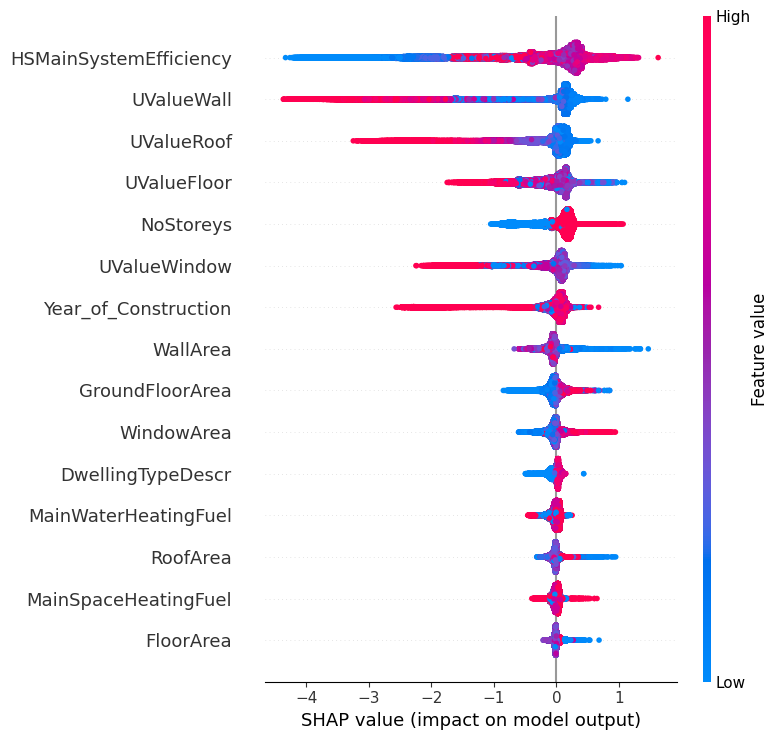

In [ ]:
# shap.summary_plot only visualises one class at a time; the most
# frequently predicted (15-point) class is used since it has the
# largest sample of test points to plot.
most_common = np.bincount(model.predict(X_test)).argmax()
print(f"Class: {target_encoder.inverse_transform([most_common])[0]}")

shap.summary_plot(sv[:, :, most_common], X_test,
                  feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3. Local explanations for example dwellings
Force plots for five hand-picked dwellings, showing that globally important features aren't always locally dominant.

In [ ]:
# Select example dwellings and show local SHAP force plots.
EXAMPLE_BANDS = ["C1", "C3", "D1", "D2", "E1"]

test_labels_series = pd.Series(y_test_labels)
example_indices = []
for band in EXAMPLE_BANDS:
    candidates = test_labels_series[test_labels_series == band].index.tolist()
    if candidates:
        example_indices.append(candidates[0]) # First match is enough for illustration.
        print(f"{band}: index {candidates[0]}")

shap.initjs()

for idx in example_indices:
    pred_class = model.predict(X_test[idx:idx+1])[0]
    sv_inst = sv[idx, :, pred_class]

    # base_values is 2D (per-class) for true multiclass output, 1D otherwise.
    ev = base_values[idx, pred_class] if base_values.ndim == 2 else base_values[idx]

    print(f"\nActual: {y_test_labels[idx]}, Predicted: {y_pred_labels[idx]}")
    display(shap.force_plot(ev, sv_inst, X_test[idx], feature_names=feature_names))

C1: index 1
C3: index 2
D1: index 7
D2: index 11
E1: index 10



Actual: C1, Predicted: C1



Actual: C3, Predicted: C3



Actual: D1, Predicted: D1



Actual: D2, Predicted: E1



Actual: E1, Predicted: D2


### 8.4. Global feature importance (bar chart)
Ranks features by mean |SHAP| value across all classes.

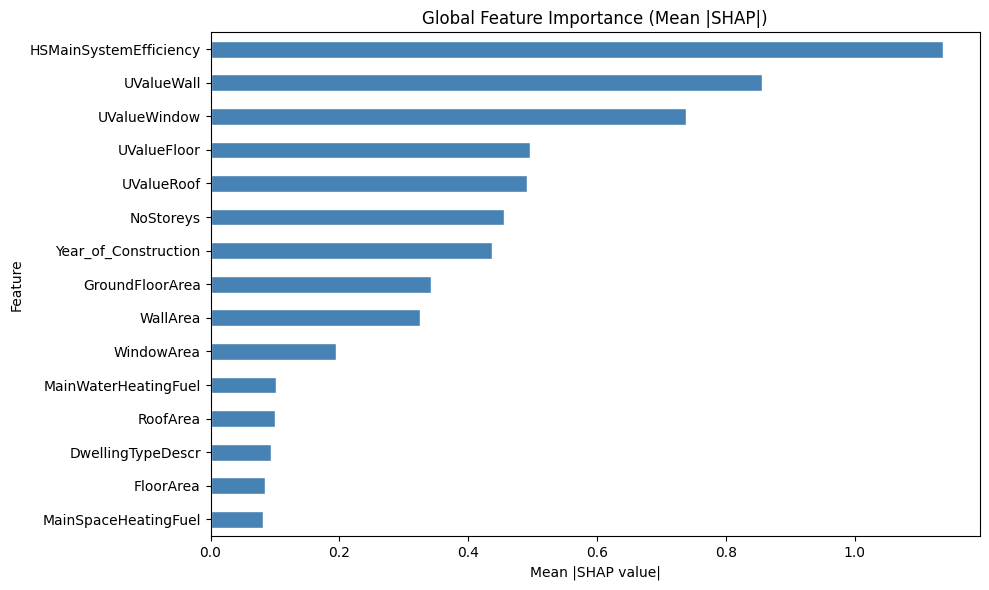

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(
    kind="barh", x="Feature", y="Mean |SHAP|",
    ax=ax, color="steelblue", edgecolor="white", legend=False
)
ax.set_title("Global Feature Importance (Mean |SHAP|)")
ax.set_xlabel("Mean |SHAP value|")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. DiCE counterfactual explanations

DiCE (Mothilal, Sharma and Tan, 2020) generates diverse counterfactual
explanations i.e. the smallest changes that would shift the predicted BER.

The key design decision is defining physical constraints on what can change:
- **Immutable:** dwelling type, year of construction, floor area, number of storeys
- **Mutable (directional):** U-values can decrease (more insulation), efficiency can increase
- **Mutable (categorical):** fuel type and glazing type can change to any valid option

### 9.1. Define retrofit constraints
Specifies which features are immutable, which must only increase/decrease (e.g. U-values can only fall), and which are freely mutable, encoding physical retrofit plausibility into the search space.

In [ ]:
# Immutable features (fixed properties of the dwelling).
IMMUTABLE_FEATURES = [
    f for f in feature_names if f in [
        "DwellingTypeDescr", "Year_of_Construction", "GroundFloorArea",
        "NoStoreys", "WallArea", "RoofArea", "FloorArea", "WindowArea",
    ]
]

# Directional constraints: U-values decrease, efficiency increases.
DIRECTIONAL_CONSTRAINTS = {}
for f in feature_names:
    # Column casing isn't consistent across the raw dataset (e.g. some
    # exports use "Uvalue" rather than "UValue"), so both forms are checked.
    if "UValue" in f or "Uvalue" in f:
        DIRECTIONAL_CONSTRAINTS[f] = "decreasing"
    elif "Efficiency" in f:
        DIRECTIONAL_CONSTRAINTS[f] = "increasing"

print(f"Immutable: {IMMUTABLE_FEATURES}")
print(f"Directional: {DIRECTIONAL_CONSTRAINTS}")

Immutable: ['DwellingTypeDescr', 'Year_of_Construction', 'GroundFloorArea', 'NoStoreys', 'WallArea', 'RoofArea', 'FloorArea', 'WindowArea']
Directional: {'UValueWall': 'decreasing', 'UValueRoof': 'decreasing', 'UValueFloor': 'decreasing', 'UValueWindow': 'decreasing', 'HSMainSystemEfficiency': 'increasing'}


### 9.2. 8-point prediction wrapper
Wraps the 15-point XGBoost model so DiCE can target the 8-point scale homeowners will actually see.

In [ ]:
# A wrapper avoids retraining a separate 8-point model: DiCE only needs a
# predict/predict_proba interface, and reusing the fitted 15-point model
# keeps this comparable to the SHAP analysis, which also runs on the
# 15-point classifier.
class BER8Wrapper:
    """Wraps the 15-point XGBoost model to predict 8-point ordinal BER.
    predict and predict_proba are consistent (predict = argmax of proba).
    predict_proba sums sub-band probabilities (e.g. P(B) = P(B1)+P(B2)+P(B3))."""

    def __init__(self, model_15, target_enc, map_15_to_8, ber_8_order):
        self.model_15 = model_15
        self.ber_8_order = ber_8_order
        # Precompute the 15-class -> 8-class index lookup, so predict_proba
        # doesn't repeat the string mapping on every call.
        _8_to_ord = {v: i for i, v in enumerate(ber_8_order)}
        self._15_to_8_idx = [
            _8_to_ord[map_15_to_8[l]] for l in target_enc.classes_
        ]
        self.classes_ = np.arange(len(ber_8_order))

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        p15 = self.model_15.predict_proba(X)
        p8 = np.zeros((p15.shape[0], len(self.ber_8_order)))
        for i15, i8 in enumerate(self._15_to_8_idx):
            p8[:, i8] += p15[:, i15]
        return p8

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


wrapper = BER8Wrapper(model, target_encoder, MAP_15_TO_8, BER_8_ORDER)

# predict_proba sums sub-band probabilities while predict takes the
# argmax — check the invariant explicitly rather than assuming it.
p = wrapper.predict(X_test[:5])
pa = np.argmax(wrapper.predict_proba(X_test[:5]), axis=1)
assert np.array_equal(p, pa), "predict / predict_proba mismatch"

print(f"Predictions: {[BER_8_ORDER[i] for i in p]} (predict/predict_proba consistent)")

Predictions: ['E', 'C', 'C', 'C', 'C'] (predict/predict_proba consistent)


### 9.3. Configure DiCE
Sets up the counterfactual generator against the training data and wrapped model.

In [ ]:
# Prepare DiCE data and model objects.
TARGET_COL = "BER_8_ord"

df_dice = pd.DataFrame(X_train, columns=feature_names)
# Re-derive 8-point labels from the 15-point training targets, then
# re-encode as a 0..7 ordinal, since DiCE needs a single numeric outcome
# column rather than the original 15-class target.
y_tr_8 = pd.Series(target_encoder.inverse_transform(y_train)).map(MAP_15_TO_8)
df_dice[TARGET_COL] = y_tr_8.map({v: i for i, v in enumerate(BER_8_ORDER)}).values

dice_data = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=[f for f in feature_names if f in num_features],
    outcome_name=TARGET_COL,
)
dice_model = dice_ml.Model(model=wrapper, backend="sklearn", model_type="classifier")
dice_exp = dice_ml.Dice(dice_data, dice_model, method="random")

available_classes = sorted(df_dice[TARGET_COL].unique())
print(f"Classes in training data: {[BER_8_ORDER[c] for c in available_classes]}")

Classes in training data: ['A', 'B', 'C', 'D', 'E', 'F', 'G']


### 9.4. Generate counterfactuals
Produces four diverse, one-band-improving counterfactuals per example dwelling under the defined constraints.

In [ ]:
NUM_CFS = 4
counterfactual_results = {}

for i, idx in enumerate(example_indices):
    query = pd.DataFrame([X_test[idx]], columns=feature_names)
    pred_ord = wrapper.predict(query)[0]
    pred_label = BER_8_ORDER[pred_ord]
    actual_15 = y_test_labels[idx]

    # Lower ordinal index means a better BER band (A0 is best, G is worst), so
    # "better" classes are simply those with a smaller index than the prediction.
    better = [c for c in available_classes if c < pred_ord]

    print(f"\n{'=' * 60}")
    print(f"EXAMPLE {i+1}: Actual {actual_15}, Predicted {pred_label}")

    if not better:
        print("No better class in training data. Skipping.")
        counterfactual_results[idx] = dict(
            actual_15=actual_15, predicted_8=pred_label,
            query=query, counterfactuals=None, error="No target")
        continue

    target = max(better)
    print(f"Target: {pred_label} -> {BER_8_ORDER[target]}")

    # Bounds are computed per dwelling, not as global constants, since a
    # valid ceiling/floor depends on that dwelling's own current value (e.g.
    # wall U-value can only fall from wherever it currently starts).
    permitted = {}
    for feat in feature_names:
        if feat in IMMUTABLE_FEATURES:
            continue
        val = float(query[feat].values[0])
        if feat in DIRECTIONAL_CONSTRAINTS:
            # Bound each feature to the physically valid side of its current
            # value: U-values may only fall (floored just above zero), and
            # efficiency may only rise (capped at a generous 100%+ ceiling).
            if DIRECTIONAL_CONSTRAINTS[feat] == "decreasing":
                permitted[feat] = [0.01, val]
            else:
                permitted[feat] = [val, 100.0]

    try:
        cf = dice_exp.generate_counterfactuals(
            query_instances=query, total_CFs=NUM_CFS,
            desired_class=int(target),
            features_to_vary=[f for f in feature_names if f not in IMMUTABLE_FEATURES],
            permitted_range=permitted or None,
            random_seed=RANDOM_STATE, # Seeding to ensure consistency of results per-run.
        )
        cf.visualize_as_dataframe(show_only_changes=True)
        cf_df = cf.cf_examples_list[0].final_cfs_df
        counterfactual_results[idx] = dict(
            actual_15=actual_15, predicted_8=pred_label,
            query=query, counterfactuals=cf_df)
        print(f"Generated {len(cf_df)} counterfactuals.")
    except Exception as e:
        print(f"DiCE failed: {e}")
        counterfactual_results[idx] = dict(
            actual_15=actual_15, predicted_8=pred_label,
            query=query, counterfactuals=None, error=str(e))


EXAMPLE 1: Actual C1, Predicted C
Target: C -> B


100%|██████████| 1/1 [00:03<00:00,  3.47s/it]

Query instance (original outcome : 3)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,8.0,2001.0,57.509998,2.0,0.55,97.510002,0.27,56.529999,0.41,57.509998,2.6,16.870001,8.0,94.099998,9.0,3



Diverse Counterfactual set (new outcome: 2)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,-,-,-,-,-,-,0.12,-,0.17,-,-,-,-,-,-,2.0
1,-,-,-,-,0.05,-,-,-,-,-,-,-,1.0,-,-,2.0
2,-,-,-,-,0.25,-,0.13,-,-,-,-,-,-,-,-,2.0
3,-,-,-,-,-,-,0.14,-,0.21,-,-,-,-,-,-,2.0


Generated 4 counterfactuals.

EXAMPLE 2: Actual C3, Predicted C
Target: C -> B


100%|██████████| 1/1 [00:02<00:00,  2.71s/it]

Query instance (original outcome : 3)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,4.0,1987.0,132.559998,1.0,0.6,105.849998,0.13,132.559998,0.57,132.559998,2.7,26.549999,8.0,88.0,9.0,3



Diverse Counterfactual set (new outcome: 2)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,-,-,-,-,0.02,-,-,-,0.02,-,-,-,-,-,-,2.0
1,-,-,-,-,-,-,-,-,0.26,-,1.2,-,-,-,-,2.0
2,-,-,-,-,-,-,-,-,0.16,-,0.7,-,-,-,-,2.0
3,-,-,-,-,0.03,-,-,-,0.03,-,-,-,-,-,-,2.0


Generated 4 counterfactuals.

EXAMPLE 3: Actual D1, Predicted D
Target: D -> C


100%|██████████| 1/1 [00:02<00:00,  2.91s/it]

Query instance (original outcome : 4)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,1.0,1999.0,151.759995,1.0,0.55,97.629997,0.4,151.759995,0.41,151.759995,2.8,54.709999,8.0,85.5,9.0,4



Diverse Counterfactual set (new outcome: 3)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,-,-,-,-,-,-,-,-,0.28,-,1.9,-,-,-,-,3.0
1,-,-,-,-,-,-,-,-,-,-,0.9,-,6.0,-,-,3.0
2,-,-,-,-,-,-,-,-,-,-,0.1,-,9.0,-,-,3.0
3,-,-,-,-,-,-,-,-,0.31,-,-,-,-,-,2.0,3.0


Generated 4 counterfactuals.

EXAMPLE 4: Actual D2, Predicted E
Target: E -> D


100%|██████████| 1/1 [00:03<00:00,  3.49s/it]

Query instance (original outcome : 5)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,8.0,1965.0,92.970001,2.0,0.86,101.389999,1.02,93.540001,0.49,92.970001,3.3,33.310001,10.0,65.0,11.0,5



Diverse Counterfactual set (new outcome: 4)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,-,-,-,-,0.27,-,-,-,-,-,1.0,-,-,-,-,4.0
1,-,-,-,-,0.16,-,-,-,-,-,-,-,-,-,-,4.0
2,-,-,-,-,-,-,-,-,-,-,-,-,6.0,85.8,-,4.0
3,-,-,-,-,-,-,0.3,-,-,-,-,-,12.0,-,-,4.0


Generated 4 counterfactuals.

EXAMPLE 5: Actual E1, Predicted D
Target: D -> C


100%|██████████| 1/1 [00:03<00:00,  3.58s/it]

Query instance (original outcome : 4)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,7.0,1975.0,37.970001,2.0,1.32,35.73,0.26,38.549999,0.61,37.970001,3.25,13.61,8.0,70.0,9.0,4



Diverse Counterfactual set (new outcome: 3)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea,NoStoreys,UValueWall,WallArea,UValueRoof,RoofArea,UValueFloor,FloorArea,UValueWindow,WindowArea,MainSpaceHeatingFuel,HSMainSystemEfficiency,MainWaterHeatingFuel,BER_8_ord
0,-,-,-,-,-,-,-,-,-,-,2.1,-,-,88.7,-,3.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,91.3,-,3.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,90.4,18.0,3.0
3,-,-,-,-,0.12,-,-,-,-,-,0.3,-,-,-,-,3.0


Generated 4 counterfactuals.


### 9.5. Readable change summaries
Decodes and prints each counterfactual's changes in feature-name/value form for manual review.

In [ ]:
for idx, r in counterfactual_results.items():
    if r["counterfactuals"] is None:
        continue
    q = r["query"].iloc[0]
    print(f"\n{'=' * 60}")
    print(f"Actual: {r['actual_15']}, Predicted: {r['predicted_8']}")
    for ci in range(len(r["counterfactuals"])):
        row = r["counterfactuals"].iloc[ci]
        new_label = BER_8_ORDER[int(row[TARGET_COL])]
        changes = cf_feature_changes(q, row, feature_names)
        print(f"\nCF{ci+1} -> {new_label} ({len(changes)} change(s)):")
        for feat, old, new in changes:
            print(decode_change(feat, old, new, cat_encoders))


Actual: C1, Predicted: C

CF1 -> B (2 change(s)):
  UValueRoof: 0.270 -> 0.120
  UValueFloor: 0.410 -> 0.170

CF2 -> B (2 change(s)):
  UValueWall: 0.550 -> 0.050
  MainSpaceHeatingFuel: Heating Oil                    -> Biodiesel from renewable sourc

CF3 -> B (2 change(s)):
  UValueWall: 0.550 -> 0.250
  UValueRoof: 0.270 -> 0.130

CF4 -> B (2 change(s)):
  UValueRoof: 0.270 -> 0.140
  UValueFloor: 0.410 -> 0.210

Actual: C3, Predicted: C

CF1 -> B (2 change(s)):
  UValueWall: 0.600 -> 0.020
  UValueFloor: 0.570 -> 0.020

CF2 -> B (2 change(s)):
  UValueFloor: 0.570 -> 0.260
  UValueWindow: 2.700 -> 1.200

CF3 -> B (2 change(s)):
  UValueFloor: 0.570 -> 0.160
  UValueWindow: 2.700 -> 0.700

CF4 -> B (2 change(s)):
  UValueWall: 0.600 -> 0.030
  UValueFloor: 0.570 -> 0.030

Actual: D1, Predicted: D

CF1 -> C (2 change(s)):
  UValueFloor: 0.410 -> 0.280
  UValueWindow: 2.800 -> 1.900

CF2 -> C (2 change(s)):
  UValueWindow: 2.800 -> 0.900
  MainSpaceHeatingFuel: Heating Oil           

## 10. Keane et al. five-deficit evaluation (RQ2)

Evaluate the generated counterfactuals against the five deficits identified by
Keane et al. (2021):
1. **Plausibility:** Are the suggested changes physically possible?
2. **Sparsity:** How many features does each counterfactual change?
3. **Diversity:** Are multiple upgrade paths offered?
4. **Actionability:** Can a homeowner realistically implement the changes?
5. **User testing:** Has the explanation been tested with real users?

### 10.1. Score plausibility, sparsity, diversity
Runs the automated directional check and computes per-dwelling sparsity/diversity metrics against the Keane framework.

In [ ]:
keane_rows = []
all_sparsities = []

for idx, r in counterfactual_results.items():
    if r["counterfactuals"] is None:
        keane_rows.append(dict(
            Dwelling=f"{r['actual_15']} ({r['predicted_8']})",
            Sparsity="N/A", Diversity="N/A",
            Plausibility="No counterfactuals generated"))
        continue

    q = r["query"].iloc[0]
    cf_df = r["counterfactuals"]
    sparsities, all_changed, issues = [], set(), []

    for ci in range(len(cf_df)):
        changes = cf_feature_changes(q, cf_df.iloc[ci], feature_names)
        sparsities.append(len(changes))
        all_sparsities.append(len(changes))
        all_changed.update(feat for feat, _, _ in changes) # Union across CFs = diversity metric.
        issues.extend(check_plausibility(changes, DIRECTIONAL_CONSTRAINTS, f"CF{ci+1}"))

    keane_rows.append(dict(
        Dwelling=f"{r['actual_15']} ({r['predicted_8']})",
        Sparsity=f"{np.mean(sparsities):.1f} ({sparsities})",
        Diversity=f"{len(all_changed)} of {len(feature_names)}",
        Plausibility="; ".join(issues) if issues else "None detected"))

keane_df = pd.DataFrame(keane_rows)
display(keane_df)

,Dwelling,Sparsity,Diversity,Plausibility
0,C1 (C),"2.0 ([2, 2, 2, 2])",4 of 15,None detected
1,C3 (C),"2.0 ([2, 2, 2, 2])",3 of 15,None detected
2,D1 (D),"2.0 ([2, 2, 2, 2])",4 of 15,None detected
3,D2 (E),"1.8 ([2, 1, 2, 2])",5 of 15,None detected
4,E1 (D),"1.8 ([2, 1, 2, 2])",4 of 15,None detected


### 10.2. Sparsity distribution
Histogram summarising how many features change per counterfactual across all 20 generated, to check homeowner-facing simplicity.


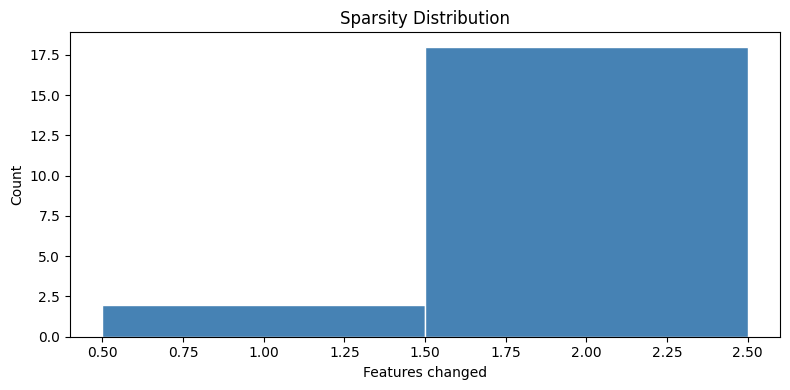

Mean: 1.9, Median: 2.0, Range: 1-2


In [ ]:
if all_sparsities:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(all_sparsities, bins=range(1, max(all_sparsities)+2),
            color="steelblue", edgecolor="white", align="left")
    ax.set_xlabel("Features changed")
    ax.set_ylabel("Count")
    ax.set_title("Sparsity Distribution")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/fig_sparsity_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Mean: {np.mean(all_sparsities):.1f}, "
          f"Median: {np.median(all_sparsities):.1f}, "
          f"Range: {min(all_sparsities)}-{max(all_sparsities)}")

## 11. Export results

Save all figures, tables, and model artefacts for the report.

### 11.1. Save tables and model artefacts
Writes performance, importance, and Keane tables to CSV and the trained model to disk for use in the report.

In [ ]:
pd.DataFrame({
    "Scale": ["15-point", "8-point"],
    "Accuracy": [f"{acc_15:.4f}", f"{acc_8:.4f}"],
    "F1 macro": [f"{f1_15:.4f}", f"{f1_8:.4f}"],
}).to_csv("table_model_performance.csv", index=False)

importance_df.to_csv(f"{RESULTS_DIR}/table_feature_importance.csv", index=False)
keane_df.to_csv(f"{RESULTS_DIR}/table_keane_evaluation.csv", index=False)
model.save_model(f"{RESULTS_DIR}/xgb_ber_model.json")

print(f"Exported to {RESULTS_DIR}: model, 3 CSV files, 6 figures.")

Exported to /content/drive/MyDrive/Colab Notebooks/Research Project/results: model, 3 CSV files, 6 figures.


### 11.2. Final summary
Prints a short run summary (dwellings processed, success/failure count, sparsity stats) as a sanity check before closing the notebook.

In [ ]:
successful = sum(1 for r in counterfactual_results.values() if r["counterfactuals"] is not None)
print(f"Dwellings: {len(counterfactual_results)}, "
      f"Successful: {successful}, Failed: {len(counterfactual_results)-successful}")
if all_sparsities:
    print(f"Sparsity: mean {np.mean(all_sparsities):.1f}, range {min(all_sparsities)}-{max(all_sparsities)}")
for _, row in keane_df.iterrows():
    print(f"  {row['Dwelling']}: {row['Plausibility']}")

Dwellings: 5, Successful: 5, Failed: 0
Sparsity: mean 1.9, range 1-2
  C1 (C): None detected
  C3 (C): None detected
  D1 (D): None detected
  D2 (E): None detected
  E1 (D): None detected


## 12. Fuel-switch policy-conflict base rate (RQ3 extension)

The five worked examples surfaced two policy-conflicting fuel switches (House Coal, banned under S.I. 529/2022; Peat Briquettes, discouraged under climate policy). This section measures how often DiCE proposes such a switch across a larger random sample of dwellings, turning the "structural but unmeasured" finding into a base rate.

In [ ]:
# Configure the policy-conflict audit. Run this cell before the audit
# below: it prints the real fuel categories so the keyword lists can be
# checked against the fixed-width truncated SEAI labels, and defines the
# classifier that labels each proposed fuel switch. A wrong keyword list
# here silently biases the whole audit, so the sanity check at the end is
# not optional.
SPACE_FUEL = "MainSpaceHeatingFuel"
WATER_FUEL = "MainWaterHeatingFuel"

# Only fuel columns with a label encoder can have their counterfactual
# codes decoded back to a fuel name.
FUEL_COLS = [c for c in (SPACE_FUEL, WATER_FUEL) if c in cat_encoders]

for c in FUEL_COLS:
    print(f"{c} categories ({len(cat_encoders[c].classes_)}):")
    for lab in cat_encoders[c].classes_:
        print(f"    {lab!r}")
    print()

# Case-insensitive substring match on the decoded label. Banned covers the
# smoky and bituminous coals prohibited under S.I. 529/2022; anthracite and
# manufactured smokeless fuels stay legal, so they are deliberately not
# matched. Discouraged covers peat, which is legal but being phased down
# under climate policy.
BANNED_KEYWORDS = ("house coal", "bituminous", "smoky")
DISCOURAGED_KEYWORDS = ("peat", "turf", "sod peat")


def classify_fuel(label):
    """Return 'banned', 'discouraged', or None for a decoded fuel label.
    Banned is tested first, so it wins if a label matches both lists.
    """
    text = str(label).lower()
    if any(k in text for k in BANNED_KEYWORDS):
        return "banned"
    if any(k in text for k in DISCOURAGED_KEYWORDS):
        return "discouraged"
    return None


# Confirm the keyword lists catch the truncated labels (e.g. House Coal,
# Peat Briquettes) and nothing legal, before the expensive run below.
print("Classification of observed fuel categories:")
for c in FUEL_COLS:
    for lab in cat_encoders[c].classes_:
        verdict = classify_fuel(lab)
        if verdict:
            print(f"    {lab!r} -> {verdict}")

MainSpaceHeatingFuel categories (19):
    'Anthracite                    '
    'Biodiesel from renewable sourc'
    'Bottled LPG                   '
    'Bulk LPG (propane or butane)  '
    'Electricity                   '
    'Electricity - Off-peak Night-R'
    'Electricity - On-peak Night-Ra'
    'Electricity - Standard Domesti'
    'Heating Oil                   '
    'House Coal                    '
    'Mains Gas                     '
    'Manufactured Smokeless Fuel   '
    'Peat Briquettes               '
    'Sod Peat                      '
    'Solid Multi-Fuel              '
    'Wood Chips                    '
    'Wood Logs                     '
    'Wood Pellets (bulk supply for '
    'Wood Pellets (in bags for seco'

MainWaterHeatingFuel categories (20):
    'Anthracite                    '
    'Biodiesel from renewable sourc'
    'Bioethanol from renewable sour'
    'Bottled LPG                   '
    'Bulk LPG (propane or butane)  '
    'Electricity                   

Auditing dwellings:   0%|          | 0/300 [00:00<?, ?it/s]


Sampled dwellings:           300
  no better-band target:     10
  DiCE failed / empty:       10
  produced counterfactuals:  280
Total counterfactuals:       1114
  fuel-switch CFs:           261 (23.4%)
  banned-fuel CFs:           12 (1.1%)
  discouraged-fuel CFs:      20 (1.8%)
  policy-conflicting CFs:    32 (2.9%)
Dwellings with >=1 conflicting CF: 31/280 (11.1%)


,Metric,Count,Share
0,Counterfactuals generated,1114,
1,Fuel-switch CFs,261,23.4%
2,Banned-fuel CFs,12,1.1%
3,Discouraged-fuel CFs,20,1.8%
4,Policy-conflicting CFs,32,2.9%
5,Dwellings w/ conflict,31,11.1%


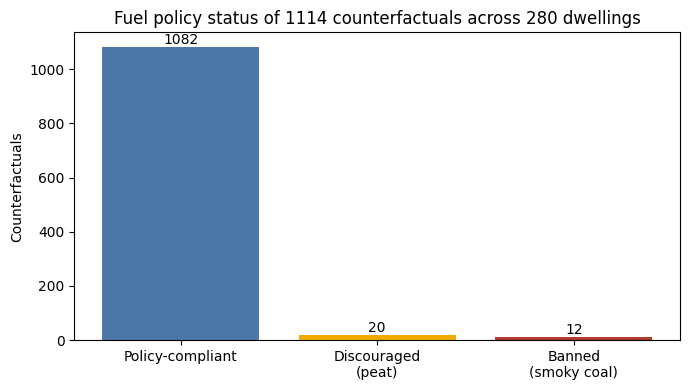

In [ ]:
# Run the policy-conflict audit over a random sample of dwellings. This
# replays the same per-dwelling counterfactual procedure as the worked
# examples above (target selection, immutable and directional constraints,
# permitted ranges, fixed seed), so the base rate is measured on the same
# footing.
#
# Note: DiCE runs once per sampled dwelling, so runtime scales
# with SAMPLE_SIZE.
import contextlib
import io

SAMPLE_SIZE = 300 # Lower to ~50 for a quick check; higher is tighter.
NUM_CFS_AUDIT = NUM_CFS if "NUM_CFS" in globals() else 4

# Seeded draw so the reported rate is reproducible.
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(
    len(X_test), size=min(SAMPLE_SIZE, len(X_test)), replace=False
)


def decode_fuel(code, col):
    """Return the fuel label for an encoded fuel code.
    DiCE returns categorical values as floats, so the code is rounded to
    the nearest integer before the inverse transform.
    """
    try:
        idx_code = int(round(float(code)))
        return cat_encoders[col].inverse_transform([idx_code])[0]
    except (ValueError, IndexError):
        return None


# Counters accumulated across the sample. Two denominators are used later:
# total_cfs for the per-counterfactual rate and with_cfs for the
# per-dwelling rate.
stats = dict(
    processed=0, no_target=0, failed=0, with_cfs=0, total_cfs=0,
    fuel_switch_cfs=0, banned_cfs=0, discouraged_cfs=0,
    conflict_cfs=0, conflict_dwellings=0,
)

for idx in tqdm(sample_idx, desc="Auditing dwellings"):
    stats["processed"] += 1
    query = pd.DataFrame([X_test[idx]], columns=feature_names)
    pred_ord = wrapper.predict(query)[0]

    # A lower ordinal is a better band, so the better classes are those
    # below the prediction, and max() picks the nearest one (a one-band
    # target). This matches the worked-example cell.
    better = [c for c in available_classes if c < pred_ord]
    if not better:
        stats["no_target"] += 1 # Already at the best band.
        continue
    target = max(better)

    # Per-dwelling permitted ranges, as in the worked-example cell. The
    # 0.01 floor keeps a decreasing U-value physical rather than zero or
    # negative; the 100.0 ceiling caps an increasing efficiency.
    permitted = {}
    for feat in feature_names:
        if feat in IMMUTABLE_FEATURES:
            continue
        val = float(query[feat].values[0])
        if feat not in DIRECTIONAL_CONSTRAINTS:
            continue
        if DIRECTIONAL_CONSTRAINTS[feat] == "decreasing":
            permitted[feat] = [0.01, val]
        else:
            permitted[feat] = [val, 100.0]

    features_to_vary = [
        f for f in feature_names if f not in IMMUTABLE_FEATURES
    ]

    # DiCE prints progress per instance, so both streams are redirected to
    # keep the loop quiet over hundreds of calls. The broad except is
    # deliberate: DiCE raises when it cannot reach the target for a
    # dwelling, and those are counted as failures rather than aborting.
    try:
        with contextlib.redirect_stdout(io.StringIO()), \
                contextlib.redirect_stderr(io.StringIO()):
            cf = dice_exp.generate_counterfactuals(
                query_instances=query,
                total_CFs=NUM_CFS_AUDIT,
                desired_class=int(target),
                features_to_vary=features_to_vary,
                permitted_range=permitted or None,
                random_seed=RANDOM_STATE,
            )
        cf_df = cf.cf_examples_list[0].final_cfs_df
    except Exception:
        stats["failed"] += 1
        continue
    if cf_df is None or len(cf_df) == 0:
        stats["failed"] += 1
        continue

    stats["with_cfs"] += 1
    dwelling_conflict = False
    for ci in range(len(cf_df)):
        row = cf_df.iloc[ci]
        stats["total_cfs"] += 1

        # Classify each counterfactual by its worst fuel change. Codes are
        # compared as integers, and a change from the query value counts as
        # a proposed switch. Banned outranks discouraged, so a single
        # counterfactual is only counted once.
        cf_switch, cf_status = False, None
        for col in FUEL_COLS:
            old_code = int(round(float(query[col].values[0])))
            new_code = int(round(float(row[col])))
            if new_code == old_code:
                continue
            cf_switch = True
            verdict = classify_fuel(decode_fuel(new_code, col))
            if verdict == "banned":
                cf_status = "banned"
            elif verdict == "discouraged" and cf_status != "banned":
                cf_status = "discouraged"
        if cf_switch:
            stats["fuel_switch_cfs"] += 1
        if cf_status == "banned":
            stats["banned_cfs"] += 1
        elif cf_status == "discouraged":
            stats["discouraged_cfs"] += 1
        if cf_status:
            stats["conflict_cfs"] += 1
            dwelling_conflict = True
    if dwelling_conflict:
        stats["conflict_dwellings"] += 1

# Summarise the counts into per-CF and per-dwelling rates. tot and den
# guard against division by zero on an empty run. The four counterfactuals
# per dwelling are not independent, so the per-dwelling rate (den) is the
# more conservative figure to quote.
tot = max(stats["total_cfs"], 1)
den = max(stats["with_cfs"], 1)
print(f"\nSampled dwellings:           {stats['processed']}")
print(f"  no better-band target:     {stats['no_target']}")
print(f"  DiCE failed / empty:       {stats['failed']}")
print(f"  produced counterfactuals:  {stats['with_cfs']}")
print(f"Total counterfactuals:       {stats['total_cfs']}")
print(f"  fuel-switch CFs:           {stats['fuel_switch_cfs']} "
      f"({stats['fuel_switch_cfs'] / tot:.1%})")
print(f"  banned-fuel CFs:           {stats['banned_cfs']} "
      f"({stats['banned_cfs'] / tot:.1%})")
print(f"  discouraged-fuel CFs:      {stats['discouraged_cfs']} "
      f"({stats['discouraged_cfs'] / tot:.1%})")
print(f"  policy-conflicting CFs:    {stats['conflict_cfs']} "
      f"({stats['conflict_cfs'] / tot:.1%})")
print(f"Dwellings with >=1 conflicting CF: "
      f"{stats['conflict_dwellings']}/{stats['with_cfs']} "
      f"({stats['conflict_dwellings'] / den:.1%})")

base_rate_df = pd.DataFrame(
    [
        ("Counterfactuals generated", stats["total_cfs"], ""),
        ("Fuel-switch CFs", stats["fuel_switch_cfs"],
         f"{stats['fuel_switch_cfs'] / tot:.1%}"),
        ("Banned-fuel CFs", stats["banned_cfs"],
         f"{stats['banned_cfs'] / tot:.1%}"),
        ("Discouraged-fuel CFs", stats["discouraged_cfs"],
         f"{stats['discouraged_cfs'] / tot:.1%}"),
        ("Policy-conflicting CFs", stats["conflict_cfs"],
         f"{stats['conflict_cfs'] / tot:.1%}"),
        ("Dwellings w/ conflict", stats["conflict_dwellings"],
         f"{stats['conflict_dwellings'] / den:.1%}"),
    ],
    columns=["Metric", "Count", "Share"],
)
base_rate_df.to_csv(
    f"{RESULTS_DIR}/table_fuel_switch_base_rate.csv", index=False
)
display(base_rate_df)

# Plot the fuel policy status of the sampled counterfactuals. The buckets
# are mutually exclusive (precedence is enforced in the loop above), so
# compliant + discouraged + banned equals total_cfs.
compliant = stats["total_cfs"] - stats["conflict_cfs"]
fig, ax = plt.subplots(figsize=(7, 4))
categories = ["Policy-compliant", "Discouraged\n(peat)",
              "Banned\n(smoky coal)"]
values = [compliant, stats["discouraged_cfs"], stats["banned_cfs"]]
ax.bar(categories, values, color=["#4c78a8", "#f2a900", "#b03a2e"])
for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("Counterfactuals")
ax.set_title(
    f"Fuel policy status of {stats['total_cfs']} counterfactuals "
    f"across {stats['with_cfs']} dwellings"
)
plt.tight_layout()
plt.savefig(
    f"{RESULTS_DIR}/fig_fuel_switch_base_rate.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## Notes

Qualitative analysis (Keane Deficit 4: Actionability, Keane summary table, and ALTAI comparison)
is presented in the written report, not in this notebook.